# PVP

In [55]:
import pandas as pd

PVP2020 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2020/datos_xml_limpios.csv')
PVP2021 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2021/datos_xml_limpios.csv')
PVP2022 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2022/datos_xml_limpios.csv')
PVP2023 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2023/datos_xml_limpios.csv')
PVP2024 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2024/datos_xml_limpios.csv')
PVP2025 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2025/datos_xml_limpios.csv')
PVP2026 = pd.read_csv('/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/PVP 2026/datos_xml_limpios.csv')




In [56]:
# Combine all yearly datasets vertically
PVP_all = pd.concat(
    [PVP2020, PVP2021, PVP2022, PVP2023, PVP2024, PVP2025, PVP2026],
    axis=0,          # stack rows
    ignore_index=True
)

# Print structure
print(PVP_all.shape)

# Preview
print(PVP_all.head())


(118631, 5)
        Fecha TerminoCosteHorario TipoPrecio  Hour       Ctd
0  01/01/2020                 FEU        Z01     1  0.107116
1  01/01/2020                 FEU        Z02     1  0.057591
2  01/01/2020                 FEU        Z03     1  0.061799
3  01/01/2020                 FEU        Z01    10  0.096981
4  01/01/2020                 FEU        Z02    10  0.048047


In [57]:
PVP_all["Fecha"] = pd.to_datetime(PVP_all["Fecha"], format="%m/%d/%Y", errors="coerce")
PVP_all["Hour"]  = pd.to_numeric(PVP_all["Hour"], errors="coerce").astype("Int64")
PVP_all["Ctd"]   = pd.to_numeric(PVP_all["Ctd"], errors="coerce")

PVP_all["datetime"] = PVP_all["Fecha"] + pd.to_timedelta(PVP_all["Hour"].fillna(0), unit="h")


In [58]:
print(PVP_all["datetime"].min(), PVP_all["datetime"].max())


2020-01-01 01:00:00 2026-02-01 00:00:00


In [59]:
PVP_all.to_csv("pvp_all.csv", index=False)


# TARIFF

In [66]:
### Defining eras based on tariff reform date

PVP_all["era"] = (PVP_all["datetime"] >= "2021-06-01").map({
    True: "post_reform",
    False: "pre_reform"
})

print(PVP_all["era"].value_counts())

era
post_reform    81413
pre_reform     37218
Name: count, dtype: int64


In [67]:
PVP_all["era"] = PVP_all["datetime"].apply(
    lambda d: "pre_reform" if d < pd.Timestamp("2021-06-01")
    else "post_reform"
)

print(PVP_all["era"].value_counts())

era
post_reform    81413
pre_reform     37218
Name: count, dtype: int64


In [68]:
coverage_by_year = (
    PVP_all.groupby(
        [PVP_all["datetime"].dt.year, "TipoPrecio"]
    )["Ctd"]
    .count()
    .unstack(fill_value=0)
)

coverage_by_year

TipoPrecio,Z01,Z02,Z03,Z14,Z24
datetime,,,,,
2020,8783,8783,8783,0,0
2021,3624,3624,3624,5136,5136
2022,0,0,0,8760,8760
2023,0,0,0,8760,8760
2024,0,0,0,8760,8760
2025,0,0,0,8545,8545
2026,0,0,0,744,744


In [69]:
### Pivot tariffs into columns:

pvp_wide = (
    PVP_all.pivot_table(
        index="datetime",
        columns="TipoPrecio",
        values="Ctd",
        aggfunc="mean"
    )
    .reset_index()
)

pvp_wide.head()

TipoPrecio,datetime,Z01,Z02,Z03,Z14,Z24
0,2020-01-01 01:00:00,0.107116,0.057591,0.061799,NaN,NaN
1,2020-01-01 02:00:00,0.104067,0.054688,0.051422,NaN,NaN
2,2020-01-01 03:00:00,0.103719,0.054117,0.050799,NaN,NaN
3,2020-01-01 04:00:00,0.100270,0.050844,0.047641,NaN,NaN
4,2020-01-01 05:00:00,0.098815,0.049464,0.046308,NaN,NaN


In [70]:
#Compare spread pre vs post reform

pvp_wide["spread"] = (
    pvp_wide[["Z01","Z02","Z03"]].max(axis=1) -
    pvp_wide[["Z01","Z02","Z03"]].min(axis=1)
)

pvp_wide["spread"].describe()

count    12406.000000
mean         0.038048
std          0.016155
min          0.018235
25%          0.018644
50%          0.047722
75%          0.050385
max          0.073465
Name: spread, dtype: float64

In [71]:
### Comparing hourly profiles weekday vs weekend
 
PVP_all["weekday"] = PVP_all["datetime"].dt.weekday

weekend_profile = (
    PVP_all.groupby(["TipoPrecio","weekday"])["Ctd"]
    .mean()
    .unstack(0)
)

weekend_profile

TipoPrecio,Z01,Z02,Z03,Z14,Z24
weekday,,,,,
0,0.102763,0.082231,0.082618,0.191911,0.191915
1,0.104172,0.083608,0.083968,0.196146,0.196149
2,0.104960,0.084406,0.084763,0.194396,0.194400
3,0.105649,0.085060,0.085438,0.193657,0.193661
4,0.103697,0.083113,0.083485,0.191305,0.191310
5,0.097935,0.077357,0.077714,0.148799,0.148799
6,0.093781,0.073257,0.073561,0.141065,0.141065


<Axes: xlabel='hour'>

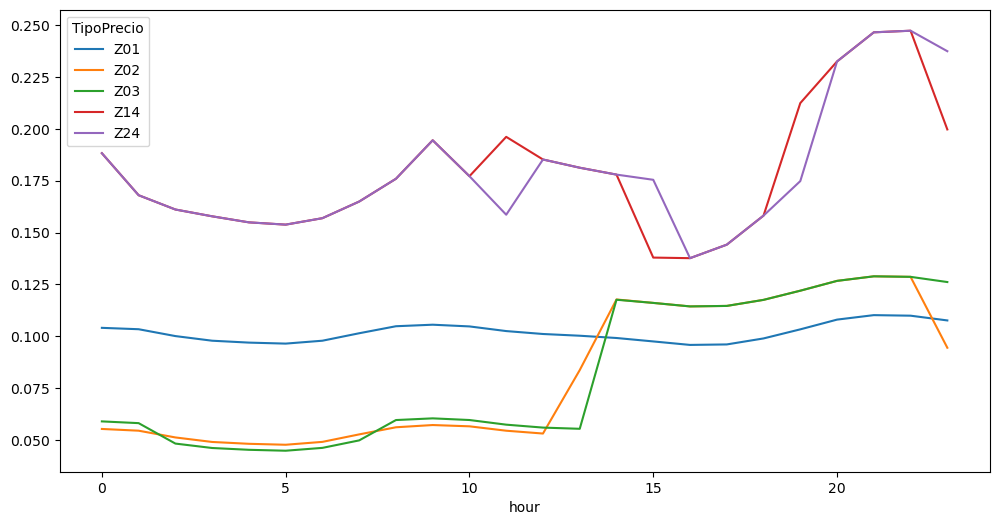

In [72]:
### Comparing hourly profiles by tariff code

PVP_all["hour"] = PVP_all["datetime"].dt.hour

profile = (
    PVP_all.groupby(["TipoPrecio","hour"])["Ctd"]
    .mean()
    .unstack(0)
)

profile.plot(figsize=(12,6))

In [73]:
PVP_all.groupby("TipoPrecio")["Ctd"].std()

TipoPrecio
Z01    0.021964
Z02    0.039842
Z03    0.040120
Z14    0.096598
Z24    0.096602
Name: Ctd, dtype: float64

# AGG

In [50]:
import os
import re
import pandas as pd
from lxml import etree

CARPETA_XML = "/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/REE_AggGenOutput"
ARCHIVO_SALIDA = "agg_gen_output_long.csv"

def parse_filename_base_dt(fname: str):
    m = re.search(r"(\d{8})(\d{2})(\d{2})", fname)
    if not m:
        return None

    ymd, hh, _rev = m.group(1), m.group(2), m.group(3)

    if hh == "24":
        base = pd.to_datetime(ymd, format="%Y%m%d")
        return base + pd.Timedelta(days=1)

    return pd.to_datetime(ymd + hh, format="%Y%m%d%H", errors="coerce")

def text(node):
    return node.text.strip() if node is not None and node.text else None

rows = []

from pathlib import Path

ROOT = Path("/Users/stephane.orts/Documents/GitHub/Projects/FInal project/Spanish Elecricity/REE_AggGenOutput")

for archivo in ROOT.rglob("*04.xml"):
    fname = archivo.name       
    ruta = str(archivo)           

    if not fname.endswith("04.xml"):
        continue

    base_dt = parse_filename_base_dt(fname)   # pass filename string
    if base_dt is None or pd.isna(base_dt):
        print(f"⚠️ Skipping (can't parse datetime): {fname}")
        continue

    tree = etree.parse(ruta)
    root = tree.getroot()

    # Iterate TimeSeries
    for ts in root.findall(".//{*}TimeSeries"):

        # Tech / generation type label (psrType)
        # In this schema it's often:
        # TimeSeries / MktPSRType / psrType
        psr = text(ts.find(".//{*}MktPSRType/{*}psrType")) or "UNKNOWN_PSR"

        # Optional helpful metadata
        business_type = text(ts.find(".//{*}businessType"))
        curve_type = text(ts.find(".//{*}curveType"))
        obj_agg = text(ts.find(".//{*}objectAggregation"))
        unit = text(ts.find(".//{*}quantity_Measure_Unit.name"))
        revision = text(ts.find(".//{*}revisionNumber"))

        # Period with time interval + resolution
        for period in ts.findall(".//{*}Period"):
            start = text(period.find(".//{*}timeInterval/{*}start"))
            res = text(period.find(".//{*}resolution"))  # e.g. PT60M

            start_dt = pd.to_datetime(start, errors="coerce")
            if pd.isna(start_dt):
                # fallback: use filename day at midnight
                start_dt = base_dt.normalize()

            # Points (position, quantity)
            for point in period.findall(".//{*}Point"):
                pos = text(point.find(".//{*}position"))
                qty = text(point.find(".//{*}quantity"))

                pos_i = pd.to_numeric(pos, errors="coerce")
                mw = pd.to_numeric(qty, errors="coerce")

                if pd.isna(pos_i) or pd.isna(mw):
                    continue

                # Most GL docs: position 1 = first interval after start_dt
                dt = start_dt + pd.to_timedelta(int(pos_i - 1), unit="h")

                rows.append({
                    "datetime": dt,
                    "psrType": psr,
                    "mw": mw,
                    "unit": unit,
                    "businessType": business_type,
                    "curveType": curve_type,
                    "objectAggregation": obj_agg,
                    "revisionNumber": revision,
                    "source_file": archivo
                })

df = pd.DataFrame(rows)

if df.empty:
    print("⚠️ No rows parsed. Next step: inspect a specific TimeSeries/Period path.")
else:
    df["mw"] = pd.to_numeric(df["mw"], errors="coerce")
    df = df.dropna(subset=["datetime", "mw"]).sort_values(["datetime", "psrType"]).reset_index(drop=True)

    print("✅ Parsed rows:", df.shape)
    print(df.head(10))

    df.to_csv(ARCHIVO_SALIDA, index=False, encoding="utf-8")
    print(f"✅ Saved: {ARCHIVO_SALIDA}")


✅ Parsed rows: (86955, 9)
                   datetime psrType      mw unit businessType curveType  \
0 2023-12-31 22:45:00+00:00     B01   248.0  MAW          A01       A01   
1 2023-12-31 22:45:00+00:00     B02     0.0  MAW          A01       A01   
2 2023-12-31 22:45:00+00:00     B03     0.0  MAW          A01       A01   
3 2023-12-31 22:45:00+00:00     B04  4660.0  MAW          A01       A01   
4 2023-12-31 22:45:00+00:00     B05   280.0  MAW          A01       A01   
5 2023-12-31 22:45:00+00:00     B06    24.0  MAW          A01       A01   
6 2023-12-31 22:45:00+00:00     B07     0.0  MAW          A01       A01   
7 2023-12-31 22:45:00+00:00     B08     0.0  MAW          A01       A01   
8 2023-12-31 22:45:00+00:00     B09     0.0  MAW          A01       A01   
9 2023-12-31 22:45:00+00:00     B10  1632.0  MAW          A01       A01   

  objectAggregation revisionNumber  \
0               A08           None   
1               A08           None   
2               A08           None

In [ ]:
### building the wide generation table

gen_wide = (
    df.pivot_table(
        index="datetime",
        columns="psrType",
        values="mw",
        aggfunc="sum"
    )
    .reset_index()
)

print(gen_wide.shape)
gen_wide.head()


(2108, 22)


psrType,datetime,B01,B02,B03,B04,B05,B06,B07,B08,B09,...,B12,B13,B14,B15,B16,B17,B18,B19,B20,B25
0,2023-12-31 22:45:00+00:00,248.0,0.0,0.0,4660.0,280.0,24.0,0.0,0.0,0.0,...,2696.0,0.0,7096.0,76.0,28.0,240.0,0.0,5388.0,0.0,NaN
1,2023-12-31 23:45:00+00:00,248.0,0.0,0.0,4316.0,280.0,20.0,0.0,0.0,0.0,...,2104.0,0.0,7096.0,76.0,28.0,248.0,0.0,5624.0,0.0,NaN
2,2024-01-01 00:45:00+00:00,228.0,0.0,0.0,4272.0,272.0,20.0,0.0,0.0,0.0,...,1948.0,0.0,7096.0,72.0,28.0,248.0,0.0,5656.0,0.0,NaN
3,2024-01-01 01:45:00+00:00,216.0,0.0,0.0,4432.0,272.0,20.0,0.0,0.0,0.0,...,1924.0,0.0,7096.0,72.0,28.0,248.0,0.0,5448.0,0.0,NaN
4,2024-01-01 02:45:00+00:00,216.0,0.0,0.0,4396.0,272.0,20.0,0.0,0.0,0.0,...,1552.0,0.0,7096.0,72.0,28.0,244.0,0.0,5240.0,0.0,NaN


In [133]:
### Creating an hourly-aligned timestamp in generation

gen_wide["datetime_hour"] = gen_wide["datetime"].dt.round("H")

/var/folders/cr/vp54c1k91ng05_b12_m0_5ljl3frmj/T/ipykernel_37934/4228946293.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  gen_wide["datetime_hour"] = gen_wide["datetime"].dt.round("H")


In [130]:
### Aggregate to one row per hour

gen_hourly = (
    gen_wide.groupby("datetime_hour", as_index=False)
            .sum(numeric_only=True)
)

In [134]:
### creating aggregated energy buckets

gen_wide["fossil_total"] = (
    gen_wide["B02"] +
    gen_wide["B03"] +
    gen_wide["B04"] +
    gen_wide["B05"]
)

gen_wide["renewable_total"] = (
    gen_wide["B01"] +
    gen_wide["B06"] +
    gen_wide["B07"] +
    gen_wide["B08"] +
    gen_wide["B09"]
)

gen_wide["nuclear"] = gen_wide["B10"]

gen_wide["total_generation"] = (
    gen_wide["fossil_total"] +
    gen_wide["renewable_total"] +
    gen_wide["nuclear"]
)


In [143]:
### Creating the Renewable share metric
 
gen_wide["renewable_share"] = (
    gen_wide["renewable_total"] /
    gen_wide["total_generation"]
)

print(gen_wide[["datetime_hour", "renewable_share"]].head(10))


psrType             datetime_hour  renewable_share
0       2023-12-31 23:00:00+00:00         0.038879
1       2024-01-01 00:00:00+00:00         0.042621
2       2024-01-01 01:00:00+00:00         0.040789
3       2024-01-01 02:00:00+00:00         0.033165
4       2024-01-01 03:00:00+00:00         0.033016
5       2024-01-01 04:00:00+00:00         0.031737
6       2024-01-01 05:00:00+00:00         0.030146
7       2024-01-01 06:00:00+00:00         0.031430
8       2024-01-01 07:00:00+00:00         0.032013
9       2024-01-01 08:00:00+00:00         0.032366


# MERGE

In [145]:
### Creating the hourly average price table

pvp_hourly = (
    PVP_all.groupby("datetime", as_index=False)
           .agg(price_mean=("Ctd","mean"))
)

In [ ]:
### Formatting datetime as timezone-aware (UTC)

pvp_hourly["datetime"] = (
    pd.to_datetime(pvp_hourly["datetime"])
    .dt.tz_localize("UTC")
)

In [138]:
### Merge AGG with price dataset

final_df = pvp_hourly.merge(
    gen_hourly,
    left_on="datetime",
    right_on="datetime_hour",
    how="left"
)

print(final_df.shape)
final_df.head()

(53106, 29)


,datetime,price_mean,datetime_hour,B01,B02,B03,B04,B05,B06,B07,...,B17,B18,B19,B20,B25,fossil_total,renewable_total,nuclear,total_generation,renewable_share
0,2020-01-01 01:00:00+00:00,0.075502,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 02:00:00+00:00,0.070059,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 03:00:00+00:00,0.069545,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 04:00:00+00:00,0.066252,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 05:00:00+00:00,0.064862,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
final_df["fossil_total"] = final_df[["B02","B03","B04","B05"]].sum(axis=1, min_count=1)
final_df["renewable_total"] = final_df[["B01","B06","B07","B08","B09"]].sum(axis=1, min_count=1)
final_df["nuclear"] = final_df["B10"]
final_df["total_generation"] = final_df[["fossil_total","renewable_total","nuclear"]].sum(axis=1, min_count=1)
final_df["renewable_share"] = final_df["renewable_total"] / final_df["total_generation"]

In [136]:
print("Rows with generation:",
      final_df["renewable_total"].notna().sum())

Rows with generation: 2060


In [137]:
# how many unique datetimes have generation?
gen_hours = final_df.loc[final_df["total_generation"].notna(), "datetime"]
print("Unique hours with gen:", gen_hours.nunique())
print("Date range with gen:", gen_hours.min(), "→", gen_hours.max())

# show which dates
print(gen_hours.dt.date.value_counts().head(10))

Unique hours with gen: 2060
Date range with gen: 2023-12-31 23:00:00+00:00 → 2026-02-01 00:00:00+00:00
datetime
2024-01-05    24
2024-01-04    24
2024-01-03    24
2024-01-07    24
2024-01-08    24
2024-01-09    24
2024-01-06    24
2024-01-10    24
2024-01-13    24
2024-01-12    24
Name: count, dtype: int64


In [ ]:
### First driver correlation

final_df[[
    "price_mean",
    "renewable_share",
    "fossil_total",
    "nuclear"
]].corr()

,price_mean,renewable_share,fossil_total,nuclear
price_mean,1.000000,-0.229738,0.510910,-0.239812
renewable_share,-0.229738,1.000000,-0.668951,-0.396984
fossil_total,0.510910,-0.668951,1.000000,0.035283
nuclear,-0.239812,-0.396984,0.035283,1.000000


# ANALYSIS

In [148]:
analysis_df = final_df.dropna(subset=["total_generation"]).copy()

analysis_df["year"] = analysis_df["datetime"].dt.year
analysis_df["month"] = analysis_df["datetime"].dt.month

# Keep January only
analysis_df = analysis_df[analysis_df["month"] == 1]

In [149]:
### Correlation for January months

corr_by_year = {}

for yr in analysis_df["year"].unique():
    
    df_year = analysis_df[analysis_df["year"] == yr]
    
    corr_matrix = df_year[[
        "price_mean",
        "renewable_share",
        "fossil_total",
        "nuclear"
    ]].corr()
    
    corr_by_year[yr] = corr_matrix
    
    print(f"\n📊 Correlations — January {yr}\n")
    print(corr_matrix)


📊 Correlations — January 2024

                 price_mean  renewable_share  fossil_total   nuclear
price_mean         1.000000        -0.256505      0.564493 -0.100537
renewable_share   -0.256505         1.000000     -0.684764 -0.480877
fossil_total       0.564493        -0.684764      1.000000  0.111053
nuclear           -0.100537        -0.480877      0.111053  1.000000

📊 Correlations — January 2025

                 price_mean  renewable_share  fossil_total   nuclear
price_mean         1.000000        -0.284931      0.500136 -0.316283
renewable_share   -0.284931         1.000000     -0.660353 -0.280672
fossil_total       0.500136        -0.660353      1.000000  0.068769
nuclear           -0.316283        -0.280672      0.068769  1.000000

📊 Correlations — January 2026

                 price_mean  renewable_share  fossil_total   nuclear
price_mean         1.000000        -0.280580      0.566188 -0.244124
renewable_share   -0.280580         1.000000     -0.695139 -0.402605
fossil_

In [117]:
### Comparison table

comparison = []

for yr in analysis_df["year"].unique():
    
    df_year = analysis_df[analysis_df["year"] == yr]
    
    corr = df_year[[
        "price_mean",
        "renewable_share",
        "fossil_total",
        "nuclear"
    ]].corr()
    
    comparison.append({
        "year": yr,
        "renewable_vs_price": corr.loc["price_mean", "renewable_share"],
        "fossil_vs_price": corr.loc["price_mean", "fossil_total"],
        "nuclear_vs_price": corr.loc["price_mean", "nuclear"]
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,year,renewable_vs_price,fossil_vs_price,nuclear_vs_price
0,2024,-0.256505,0.564493,-0.100537
1,2025,-0.284931,0.500136,-0.316283
2,2026,-0.280580,0.566188,-0.244124


In [118]:
comparison_df.describe()

,year,renewable_vs_price,fossil_vs_price,nuclear_vs_price
count,3.0,3.000000,3.000000,3.000000
mean,2025.0,-0.274005,0.543606,-0.220315
std,1.0,0.015311,0.037655,0.109826
min,2024.0,-0.284931,0.500136,-0.316283
25%,2024.5,-0.282755,0.532315,-0.280204
50%,2025.0,-0.280580,0.564493,-0.244124
75%,2025.5,-0.268542,0.565341,-0.172330
max,2026.0,-0.256505,0.566188,-0.100537


<Figure size 1000x600 with 0 Axes>

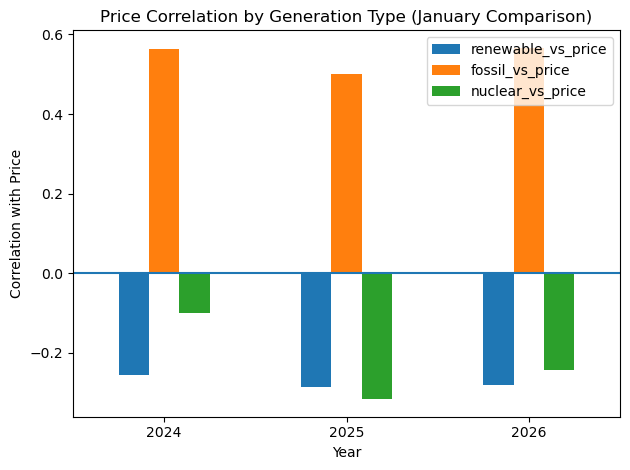

In [ ]:
import matplotlib.pyplot as plt

# Set index to year
plot_df = comparison_df.set_index("year")

plt.figure(figsize=(10,6))
plot_df.plot(kind="bar")
plt.title("Price Correlation by Generation Type (January Comparison)")
plt.ylabel("Correlation with Price")
plt.xlabel("Year")
plt.axhline(0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

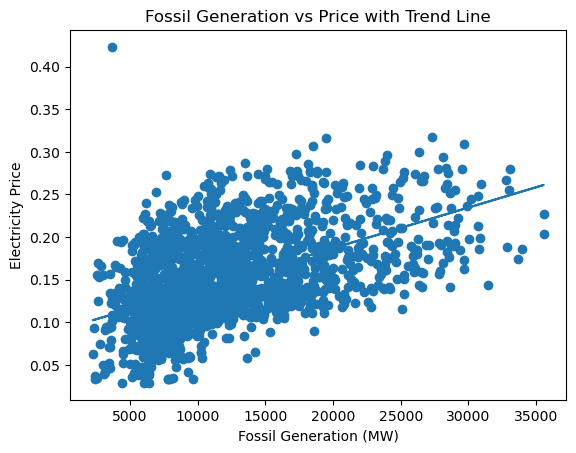

In [ ]:
import numpy as np

x = analysis_df["fossil_total"]
y = analysis_df["price_mean"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Fossil Generation (MW)")
plt.ylabel("Electricity Price")
plt.title("Fossil Generation vs Price with Trend Line")
plt.show()